# SmartLender - Applicant Credit Risk Analytics
This notebook demonstrates importing the libraries, reading the dataset, performing univariate/bivariate analysis, data preprocessing (imputation, mapping, SMOTE class balancing, and scaling), model training, evaluation, and saving the model/scaler for deployment.

## 1. Importing the Libraries
Import the necessary libraries as shown below. For this project, the visualization style **fivethirtyeight** is used for consistent and readable plots.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

## 2. Read the Dataset
The dataset may be in .csv, Excel, .txt, or .json format. Use the pandas library to read it. The **read_csv()** function is used to load the dataset by passing the file directory path as a parameter.

In [2]:
#importing the dataset which is in csv file
data = pd.read_csv('../Dataset/loan_prediction.csv')
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## 3. Exploratory Data Analysis
Univariate analysis is performed to examine the distribution and characteristics of individual features in the dataset.
- **Distribution plots (Distplot)** are used to visualize continuous variables and understand their data distribution.
- **Count plots (Countplot)** are used for categorical variables to display the frequency of each category.
- Subplots enable multiple feature visualizations within a single figure for easier comparison.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\3010789317.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['ApplicantIncome'], color='r')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13276\3010789317.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Credit_History'])


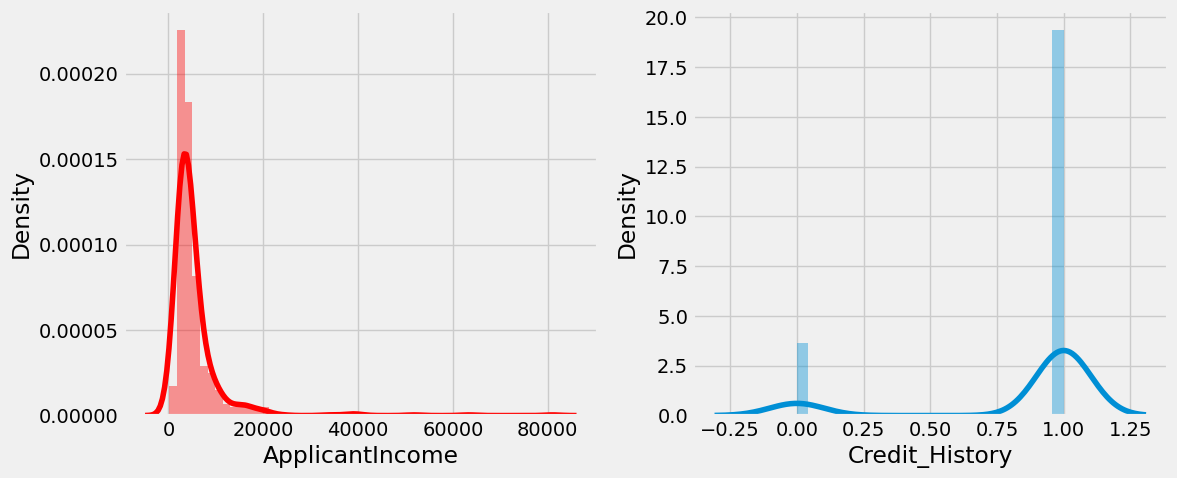

In [3]:
#plotting the using distplot
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.distplot(data['ApplicantIncome'], color='r')
plt.subplot(122)
sns.distplot(data['Credit_History'])
plt.show()

For categorical features, the **countplot** function is used to count and display the unique categories. A dummy DataFrame is created with categorical features and plotted using a for loop with subplot.

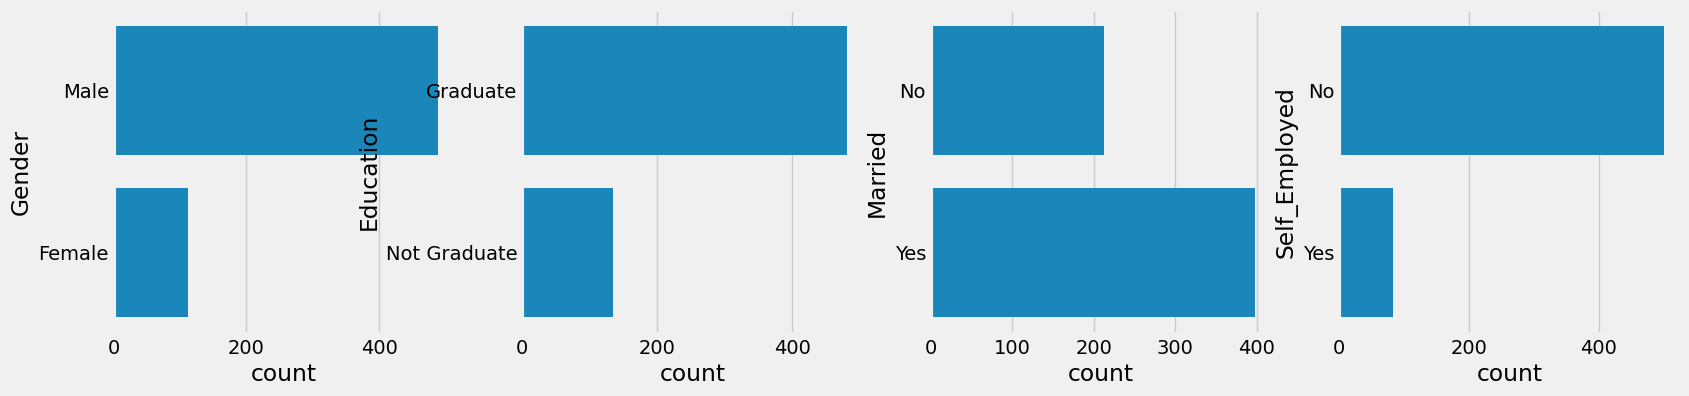

In [4]:
#plotting the count plot
plt.figure(figsize=(18,4))
plt.subplot(1,4,1)
sns.countplot(data['Gender'])
plt.subplot(1,4,2)
sns.countplot(data['Education'])
plt.subplot(1,4,3)
sns.countplot(data['Married'])
plt.subplot(1,4,4)
sns.countplot(data['Self_Employed'])
plt.show()

Bivariate Analysis

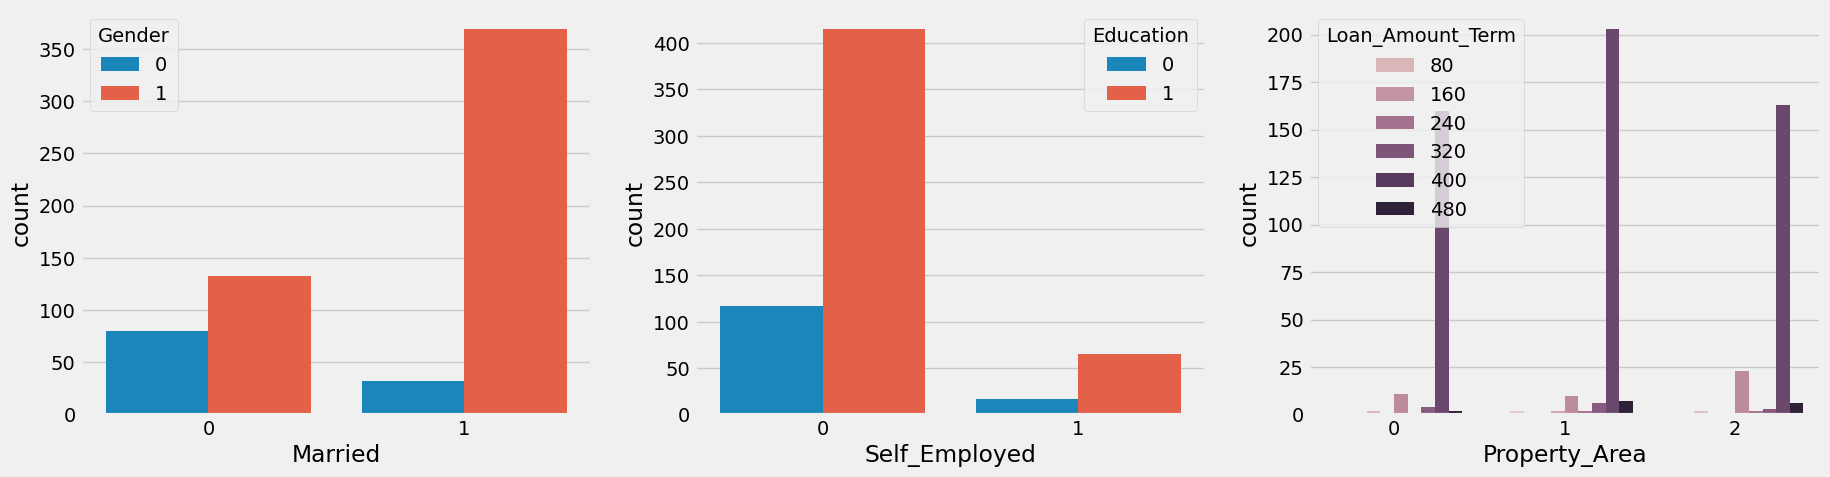

In [12]:
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(x='Married', hue='Gender', data=data)

plt.subplot(132)
sns.countplot(x='Self_Employed', hue='Education', data=data)

plt.subplot(133)
sns.countplot(x='Property_Area', hue='Loan_Amount_Term', data=data)

plt.show()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 39.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


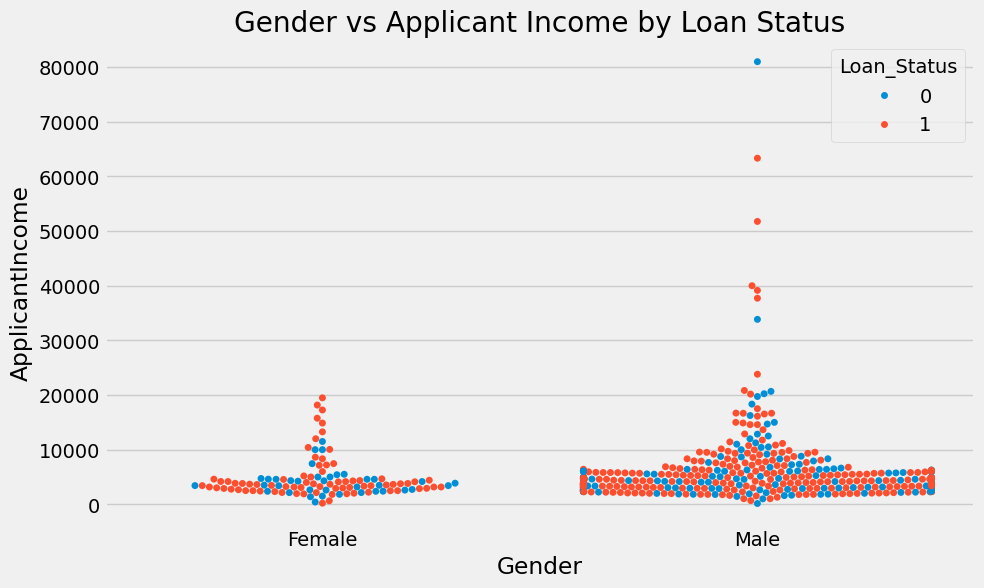

In [14]:
plt.figure(figsize=(10,6))

sns.swarmplot(
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status',
    data=data
)

plt.xticks([0,1], ['Female','Male'])
plt.title("Gender vs Applicant Income by Loan Status")
plt.show()

### Observations:
- Applicant income exhibits a **left-skewed distribution**.
- Credit history is a **binary feature** with values 0 and 1.
- Gender and education are **categorical variables** with two categories each.
- The frequency of category 0 is higher than category 1 for both gender and education features.

This analysis helps identify feature patterns and distributions before proceeding with data preprocessing and model development.

## 4. Data Preprocessing
We need to clean the data, impute missing values, map the categorical variables to numbers, perform class balancing using SMOTE, and scale the features using StandardScaler.

In [5]:
# Check for null values
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
# Impute missing values with mode for categorical columns and median/mode for numerical
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].median())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])

In [15]:
# Preprocess Dependents column and Map features
data['Dependents'] = data['Dependents'].astype(str).str.replace('+', '', regex=False).astype(int)

gender_map = {'Male': 1, 'Female': 0}
married_map = {'Yes': 1, 'No': 0}
education_map = {'Graduate': 1, 'Not Graduate': 0}
self_employed_map = {'Yes': 1, 'No': 0}
property_area_map = {'Urban': 2, 'Semiurban': 1, 'Rural': 0}
loan_status_map = {'Y': 1, 'N': 0}

data['Gender'] = data['Gender'].map(gender_map)
data['Married'] = data['Married'].map(married_map)
data['Education'] = data['Education'].map(education_map)
data['Self_Employed'] = data['Self_Employed'].map(self_employed_map)
data['Property_Area'] = data['Property_Area'].map(property_area_map)
data['Loan_Status'] = data['Loan_Status'].map(loan_status_map)

X = data.drop(columns=['Loan_ID', 'Loan_Status'])
y = data['Loan_Status']

In [8]:
# Split the data & apply SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Original training dataset shape:', y_train.value_counts().to_dict())
print('Resampled training dataset shape:', y_train_res.value_counts().to_dict())

Original training dataset shape: {1: 342, 0: 149}
Resampled training dataset shape: {0: 342, 1: 342}


In [9]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

## 5. Model Training & Comparison

In [10]:
# Train and evaluate models
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train_res)
dt_preds = dt.predict(X_test_scaled)
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_preds))

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train_res)
knn_preds = knn.predict(X_test_scaled)
print('KNN Accuracy:', accuracy_score(y_test, knn_preds))

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_res)
rf_preds = rf.predict(X_test_scaled)
print('Random Forest Accuracy:', accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_scaled, y_train_res)
gb_preds = gb.predict(X_test_scaled)
print('Gradient Boosting Accuracy:', accuracy_score(y_test, gb_preds))

Decision Tree Accuracy: 0.7235772357723578
KNN Accuracy: 0.7073170731707317
Random Forest Accuracy: 0.7398373983739838
              precision    recall  f1-score   support

           0       0.69      0.47      0.56        43
           1       0.76      0.89      0.82        80

    accuracy                           0.74       123
   macro avg       0.72      0.68      0.69       123
weighted avg       0.73      0.74      0.73       123

Gradient Boosting Accuracy: 0.7479674796747967


## 6. Pickling the Model and Scaler
We save the standard scaler and the Random Forest model for consumption in our Flask web app.

In [11]:
import os
os.makedirs('../Flask', exist_ok=True)

with open('../Flask/rdf.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../Flask/scale1.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../Flask/scale1(1).pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Models and scalers saved successfully in the Flask directory!')

Models and scalers saved successfully in the Flask directory!
